# Lab 3: Pretraining a GPT model

This lab is about pretraining large language models (LLMs). You will work through the full pretraining process for a GPT model, explore different settings, and implement optimisations that make training more efficient. You will also reflect on the impact of data curation on the quality of the pretrained model. By the end of the lab, you will have a solid understanding of how LLMs are trained from scratch.

*Tasks you can choose for the oral exam are marked with the graduation cap 🎓 emoji.*

In [1]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gpt2 import Config, Model

## Part 1: Pretraining pipeline

### Training configuration

We begin by setting up a configuration object that defines the key parameters of the training process.

The original 124M-parameter GPT-2 model released by OpenAI (and featured in lab&nbsp;2) was trained on WebText, a private dataset with approximately 10B tokens of Internet data. (There is no reliable public source that reports the exact number.) We will refer to this model as **Model&nbsp;A**.

The training pipeline in this lab is configured to train a Chinchilla-optimal model with the same architecture as Model&nbsp;A but using the publicly released [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) dataset. We will refer to this model as **Model&nbsp;B**.

In [2]:
@dataclass
class TrainingConfig:
    device: torch.device = torch.device("cuda")     # we are saying that use the NVIDIA GPU "cuda" for training
    shard_dir: str = "/courses/TDDE09/tdde09/labs/lab3/data" # shard are the smaller chunks of data and will be stored on the directory "data"

    # Training steps and data processing
    n_steps: int = 4768                              # The total number of training iterations where the weitghs get updated for each iteration.
    n_tokens_per_step: int = 524288                  # The number of tokens processed in each training step which is equal = batch_size * sequence_len * gradient.
    batch_size: int = 8                            # The number of sequences that can be processed in parallell, during each fprward/backward pass. for a batch_size of 64, 64 deifferent text sequences are processed simultaneously.
    sequence_len: int = 1024                         # The number of the input text converted to to tkens. Each sequence is 1024 tokens long (about 750-800 words)
    n_vocab: int = 50304                             # The size of the models vocabulary, 

    # Optimisation and learning rate scheduling
    weight_decay: float = 0.1                        # L2 regulation coefficient to prevent overfitting. adds a penalty to loss function to keep the weights to stay small.                   
    max_lr: float = 6e-4                             # The initial learning rate at the start of training, which controls how much the model's weights are updated during each training step. A higher learning rate can lead to faster convergence but may also cause instability, while a lower learning rate can lead to more stable training but may require more iterations to converge.
    min_lr: float = 6e-5                             # The minimum learning rate at the end of training, which is the lowest learning rate that the model will reach during training. This is used in learning rate scheduling to gradually decrease the learning rate as training progresses, allowing the model to fine-tune its weights and converge to a better solution.    
    n_warmup_steps: int = 715                        # The number of initial training steps during which the learning rate will increase linearly from 0 to the maximum learning rate (max_lr). This is used to help stabilize training in the early stages and prevent large updates to the model's weights before it has had a chance to learn useful features from the data.
    n_decay_steps: int = 4053                        # The number of training steps during which the learning rate will decrease linearly from the maximum learning rate (max_lr) to the minimum learning rate (min_lr). This is used to allow the model to fine-tune its weights and converge to a better solution as training progresses.
    betas: tuple[float, float] = (0.9, 0.95)         # The betas for the Adam optimizer, used to control the exponential decay rates for the first and second moments of the gradients.
    clip_norm: float = 1.0                           # The maximum norm of the gradients before they are clipped to prevent exploding gradients.

#### 🎓 Task 3.01: Explaining the training parameters

Your first task is to explain the purpose of the training parameters. Some of them will already be known to you from the lectures, while others will become clear first as you progress through the lab and see how everything fits together. Because of this, it is best to revisit and complete this task towards the end of the lab when you have a full understanding of the training process.

ANSWER: Check the comments in the code.     

One parameter to note is the vocabulary size. GPT-2 uses 50,257 tokens, but for training on a GPU, it is helpful to have numbers that are more hardware-friendly. Specifically, numbers with many factors of&nbsp;2 can lead to more efficient computation. To achieve this, we set the vocabulary size to 50,304, which is slightly larger than needed but has many factors of&nbsp;2. Note that the extra tokens will not be used in practice — they simply act as placeholders without meaningful embeddings.

Next, we set up the model. Our goal is to match the original training setup of GPT-2 as closely as possible. To do this, we follow the initialisation strategy outlined in the key research papers about GPT ([Radford et al., 2018](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf); [Radford et al., 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf); [Brown et al., 2020](https://arxiv.org/pdf/2005.14165)) as well as the official implementation ([link](https://github.com/openai/gpt-2)). Here is a summary of this strategy:

* Token embeddings → Normal distribution with mean $0$ and standard deviation $0.02$.
* Position embeddings → Normal distribution with mean $0$ and standard deviation $0.01$.
* Weights of the linear layers → Normal distribution with mean $0$ and standard deviation $0.02$.
* Biases of the linear layers → Initialised to zeros.
* Weight sharing between the final linear layer and the token embedding.

#### 🧩 Task 3.02: Initialising the model

Expand the skeleton code below to create a fresh model and initialise it according to the GPT-2 strategy.

NOTES: Before a neural network begins training, its mathematical "brain" is completely blank. We have to fill its matrices with starting numbers. this is called weight initialization. 

In [3]:
def configure_model(config: TrainingConfig) -> Model:
    # TODO: Replace the following line with your own code
    model = Model(Config(n_vocab=config.n_vocab))

    N = 2 * Config.n_layer # The number of layers in the model, which is used to calculate the residual scale for weight initialization. The residual scale is a factor that helps to stabilize training by scaling the weights of certain layers, such as the projection layers (c_proj), based on the depth of the model. In this case, it is calculated as 1.0 divided by the square root of N, where N is the number of layers in the model.
    residual_scale = 1.0 / math.sqrt(N)

    for name, module in model.named_modules(): # The named_modules() method is a function in PyTorch that returns an iterator over all the modules (layers) in a neural network model, along with their names. It allows you to access and manipulate the individual layers of the model by their names, which can be useful for tasks such as weight initialization, fine-tuning, or applying specific operations to certain layers. In this code snippet, it is used to iterate through all the layers of the model and apply different weight initialization strategies based on the type of layer and its name.
        if isinstance(module, nn.Linear): # the function isinstance() is used to check if the module is an instance of the nn.Linear class, which represents a fully connected linear layer in a neural network. If the module is indeed a linear layer, the code inside this block will be executed to initialize its weights and biases.
            std = 0.02
            if "c_proj" in name:
                std = 0.02 * residual_scale # The standard deviation for initializing the weights of the projection layers (c_proj) is scaled by the residual scale, which is calculated based on the number of layers in the model. This helps to stabilize training by preventing the weights from becoming too large or too small as the model depth increases.
                
            nn.init.normal_(module.weight, mean=0.0, std=std) # The weights of the linear layer are initialized using a normal distribution with a mean of 0.0 and a standard deviation defined by the variable std. This is a common weight initialization strategy that helps to ensure that the weights are not too large or too small, which can help to stabilize training and improve convergence.
            if module.bias is not None: # If the linear layer has a bias term (i.e., if module.bias is not None), then the biases are initialized to zero using the nn.init.zeros_() function. Initializing biases to zero is a common practice that can help to ensure that the model starts with a neutral bias and allows the weights to learn meaningful patterns from the data during training.
                nn.init.zeros_(module.bias)
    
        elif isinstance(module, nn.Embedding):
            if "wpe" in name:
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
            else:
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    model.lm_head.weight = model.wte.weight # the language modeling head (lm_head) is tied to the word embedding layer (wte) by sharing their weights. This means that the weights of the lm_head are set to be the same as the weights of the wte, which can help to improve the performance of the model by allowing it to leverage the learned word embeddings for language modeling tasks. Tying the weights in this way can also reduce the number of parameters in the model, which can help to prevent overfitting and improve generalization.
    return model

# a conclusion about the code above is that it defines a function called configure_model that takes a TrainingConfig object as input and returns an instance of the Model class. The function initializes the weights of the model's layers using different strategies based on the type of layer and its name, which helps to stabilize training and improve convergence. The model's language modeling head (lm_head) is also tied to the word embedding layer (wte) by sharing their weights.

#### Scaled residual initialisation

There is one important detail in the GPT-2 initialisation strategy that we have not addressed yet. [Radford et al. (2019)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) write (Section&nbsp;2.3):

> A modified initialization which accounts for the accumulation on the residual path with model depth is used. We scale the weights of residual layers at initialization by a factor of $1/\sqrt{N}$ where $N$ is the number of residual layers.

Why is this necessary? One of the challenges in training large language models is controlling the variance of activations. However, there are two points in the GPT architecture where variance can grow uncontrollably: the residual connections after the multi-head attention and the MLP. Since these connections simply add activations from previous layers, their variances increase with depth. To see this, note that if we sum $N$ independent normally distributed variables with variance $\sigma^2$, the result has variance $N \sigma^2$.

#### 🎓 Task 3.03: Implementing the scaled residual initialisation

**Step&nbsp;1.** Suppose each summand in a sum of $N$ independent normally distributed variables with variance $\sigma^2$ is scaled by a factor of&nbsp;$k$. The total variance then becomes $N k^2 \sigma^2$. What happens to the total variance if we choose $k = 1/\sqrt{N}$, as in GPT-2? 

ANSWER: The total variance is $\sigma^2$.

Target scaling factor: k=N​1​

New Variance per layer: k2⋅σ2=(N​1​)2⋅σ2=N1​σ2

Summing N layers: N⋅(N1​σ2)=σ2


**Step&nbsp;2.** Test the mathematical theory with a simulation. Generate normally distributed activations using `torch.randn()`. Sum the activations across $N$ hypothetical residual layers, first without scaling and then with the $1/\sqrt{N}$ adjustment. Compare the two cases by producing a plot showing the variance at each layer. To compute the variance of a tensor, use `torch.var()`.

ANSWER: Check the code below.

**Step&nbsp;3.** Update your model initialisation from the previous task to include the scaled residual initialisation. The adjustment should only be applied to the linear layer at the end of the multi-head attention and MLP blocks (`c_proj`). Note that a GPT model with $L$&nbsp;layers has $N = 2 L$ residual layers, because there are two residual connections in each layer (after the multi-head attention and the MLP).

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1053731/138681313.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Variance ($\sigma^2$)")


initial: tensor([ 1.3474e+00,  3.3187e-01,  1.4823e+00,  6.8963e-01, -1.0804e+00,
        -6.7945e-02, -8.9499e-02, -1.3822e+00,  1.1390e+00, -6.7676e-01,
        -1.5569e+00, -8.0758e-02,  8.4070e-01,  8.4957e-01,  1.8722e+00,
         1.1476e+00, -1.1315e+00, -1.4278e+00, -8.2961e-01, -9.8679e-01,
         1.4334e+00, -1.7361e+00,  1.2974e-01,  4.1510e-01, -1.3656e+00,
         1.9757e+00, -1.1036e-03, -1.3528e+00, -9.5986e-01,  9.1271e-01,
        -1.9793e-01,  5.4241e-01,  1.4350e+00, -3.2420e-01, -1.0301e+00,
         2.7186e-01,  4.9083e-01, -4.2673e-01, -1.8027e-01, -8.2969e-01,
        -1.9105e-01,  6.5907e-03,  5.8429e-02,  1.8081e-01,  3.7152e-01,
        -4.8164e-01, -1.1968e+00,  5.4170e-02,  7.2030e-01, -7.5423e-02,
         6.9543e-01, -8.3198e-01, -3.5245e-01, -5.3481e-01,  1.9294e-01,
        -1.8817e+00, -3.9900e-01, -4.0305e-01,  8.9995e-01,  9.0021e-01,
         9.2046e-02, -7.9074e-01, -2.0827e+00, -3.2085e-01,  1.0010e+00,
        -2.8411e-01, -6.5566e-01, -8.9118e

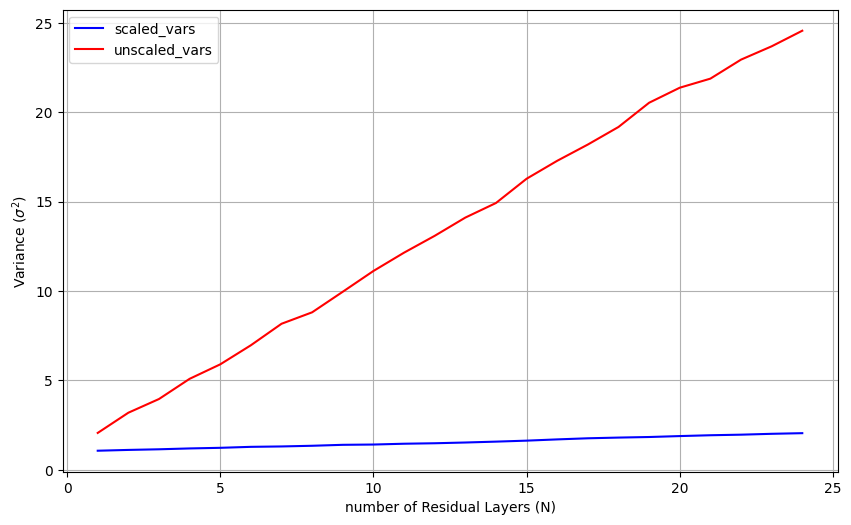

In [4]:
#Q2 3.03
import matplotlib.pyplot as plt
def simulate_var(N_layers: int, scale: bool):
    
    x = torch.randn(1000)
    print(f"initial: {x}")
    var = []

    for _ in range(N_layers):

        layer_out = torch.randn(1000)
        #print(f"dassf: {layer_out}")
        if scale:
            layer_out = layer_out * (1.0 / math.sqrt(N_layers))

        x = x + layer_out
        var.append(torch.var(x).item())
    return var

unscaled_vars = simulate_var(N_layers= 24, scale=False)
print(f" Unscaled: {unscaled_vars}")
scaled_vars = simulate_var(N_layers= 24, scale=True)
print(f"Scaled: {scaled_vars}")

#plot 
plt.figure(figsize=(10, 6))
plt.plot(range(1,25), scaled_vars, label="scaled_vars", color="blue")
plt.plot(range(1,25), unscaled_vars, label="unscaled_vars", color="red")
plt.xlabel("number of Residual Layers (N)")
plt.ylabel("Variance ($\sigma^2$)")
plt.legend()
plt.grid(True)
plt.show()


### Data

As mentioned before, the original Model&nbsp;A was pretrained on a 10B-token non-public dataset collected by OpenAI. The pretraining data for our Model&nbsp;B comes from the public [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) dataset. The full dataset contains 1.3&nbsp;trillion tokens, much more than what we need to train a Chinchilla-optimal model. (How much is that?)

In this lab, we will mostly work with a tiny sample of the full pretraining data for Model&nbsp;B. We use a preprocessed version of the data that has been tokenised with the GPT-2 tokeniser and chopped into smaller chunks called **shards**. The function below loads these shards from a given directory and yields them as PyTorch tensors.

In [5]:
def shards(shard_dir: str): # shrard_dir is the directory where the data shards are stored. Each shard is a smaller chunk of the dataset that can be loaded into memory for training. The function will iterate through all the files in the specified directory, load each shard using numpy's load function, convert it to a PyTorch tensor, and yield it one at a time for use in training.
    for shard in sorted(os.listdir(shard_dir)):
        yield torch.from_numpy(np.load(os.path.join(shard_dir, shard), allow_pickle=True).astype(np.int64))

In total, our training data consists of 300M tokens:

In [6]:
import numpy as np
load_file = np.load("/courses/TDDE09/tdde09/labs/lab3/data/edufineweb_train_000001.npy", allow_pickle=True)
print(len(load_file), load_file.shape)

100000000 (100000000,)


In [7]:
sum(s.numel() for s in shards(TrainingConfig().shard_dir))

300000000

In [8]:
[(s.shape, s) for s in shards(TrainingConfig().shard_dir)]

[(torch.Size([100000000]),
  tensor([ 2982,    11,  2026,  ...,   307, 35112,   422])),
 (torch.Size([100000000]),
  tensor([  884, 24672,    13,  ...,  1290,   355, 32217])),
 (torch.Size([100000000]), tensor([3011,   13, 4101,  ..., 1107,  761,  284]))]

#### 🎓 Task 3.04: Batching the data

Implement a function `make_batches()` that packages the token indices in the shards into pairs of input and output batches suitable for language modelling training. One efficient way to do this is sketched in the cell below:

In [9]:
shard = torch.tensor(range(15), dtype=torch.long)
print(f"shard: {shard}")

# Suppose we want to package the tokens in this shard into batches of shape (2, 3).

# Step 1: Segment the shard into overlapping chunks of size 2 * 3 + 1
chunk1 = shard[0:7]
chunk2 = shard[6:13]
excess = shard[12:]
print(f"chunk1: {chunk1}")
print(f"chunk2: {chunk2}")
print(f"excess: {excess}")

# Step 2: Create batches from all but the last and all but the first token in each chunk
x1, y1 = chunk1[:-1].view(2, 3), chunk1[1:].view(2, 3)
print(f"x1: {x1}")
print(f"y1: {y1}")
x2, y2 = chunk2[:-1].view(2, 3), chunk2[1:].view(2, 3)

shard: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
chunk1: tensor([0, 1, 2, 3, 4, 5, 6])
chunk2: tensor([ 6,  7,  8,  9, 10, 11, 12])
excess: tensor([12, 13, 14])
x1: tensor([[0, 1, 2],
        [3, 4, 5]])
y1: tensor([[1, 2, 3],
        [4, 5, 6]])


The following code cell shows the signature of `make_batches()`.

In [10]:
def make_batches(config: TrainingConfig):
    # TODO: Replace the following line with your own code
    token_per_batch = config.batch_size * config.sequence_len # The total number of tokens that will be processed in each training step, which is calculated as the product of the batch size and the sequence length. This represents the number of tokens that will be fed into the model during each forward and backward pass, and is used to determine how to segment the input data into batches for training.
    print (f"token_per_batch: {token_per_batch}")
    chunk_size = token_per_batch + 1
    print(f"chunk_size: {chunk_size}")

    buffer = torch.empty(0, dtype=torch.long)
    print(f"Initial buffer size: {len(buffer)}")
    for shard in shards(config.shard_dir): # The shards() function is a generator that yields tensors containing the tokenized data from the specified shard directory. Each shard is a smaller chunk of the overall dataset, and the make_batches function processes these shards to create batches of data for training. The buffer variable is used to accumulate tokens from the shards until there are enough tokens to create a batch of the desired size (token_per_batch). Once there are enough tokens in the buffer, it creates batches by segmenting the buffer into overlapping chunks and yields the input (x) and target (y) tensors for training.
        buffer = torch.cat([buffer, shard]) # for example, if the buffer currently contains 1000 tokens and the new shard contains 500 tokens, the torch.cat() function will concatenate them to create a new buffer containing 1500 tokens. This allows the make_batches function to accumulate tokens from multiple shards until there are enough tokens to create a batch of the desired size (token_per_batch).
        n_tokens = len(buffer) 
        n_batches = n_tokens // token_per_batch 
        print(f"Tokens in buffer: {n_tokens}, Batches: {n_batches}")
        while len(buffer) >= chunk_size: # as long as there are 65537 tokens in the buffer, the loop will continue to create batches by segmenting the buffer into overlapping chunks of size chunk_size (which is token_per_batch + 1). The loop will yield the input (x) and target (y) tensors for training until there are fewer than chunk_size tokens left in the buffer, at which point it will exit the loop and wait for more tokens to be added from the next shard.
            chunk = buffer[:chunk_size]
            x = chunk[:-1].view(config.batch_size, config.sequence_len)
            y = chunk[1:].view(config.batch_size, config.sequence_len)
            yield x, y
            buffer = buffer[token_per_batch:]

In [11]:
config = TrainingConfig()
batches = make_batches(config)
x, y = next(batches)
print(f"Shape of x: {x.shape} (Expected: ({config.batch_size}, {config.sequence_len}))")
print(f"Shape of y: {y.shape} (Expected: ({config.batch_size}, {config.sequence_len}))")

print(f"First batch of x:\n{x}")
print(f"First batch of y:\n{y}")
batch_count = 0
for x, y in batches:
    batch_count += 1
print(f"number of batches: {batch_count} ")

token_per_batch: 8192
chunk_size: 8193
Initial buffer size: 0
Tokens in buffer: 100000000, Batches: 12207
Shape of x: torch.Size([8, 1024]) (Expected: (8, 1024))
Shape of y: torch.Size([8, 1024]) (Expected: (8, 1024))
First batch of x:
tensor([[ 2982,    11,  2026,  ...,   890,   640,  1201],
        [10433,   468,   587,  ...,  4461,   393,  4425],
        [  257,  5852,   706,  ..., 19104,   290,   720],
        ...,
        [   13,    50,    13,  ..., 15209, 18160,  1578],
        [ 1829,   355,  3402,  ...,  1588,  2055,    12],
        [15808,  5043,    13,  ...,    11, 28494,  1818]])
First batch of y:
tensor([[   11,  2026,  1510,  ...,   640,  1201, 10433],
        [  468,   587,   319,  ...,   393,  4425,   257],
        [ 5852,   706,   262,  ...,   290,   720, 20219],
        ...,
        [   50,    13,  1751,  ..., 18160,  1578,  1829],
        [  355,  3402,   287,  ...,  2055,    12, 15808],
        [ 5043,    13,   198,  ..., 28494,  1818,   460]])
Tokens in buffer: 1000

**Hints and considerations:**

* Batches can stretch across shards. You will have to carry over excess tokens at the end of shards to the next batch.
* All batches should have the same shape. Drop excess tokens at the end of the last shard.
* The correct number of batches of shape $(64, 1024)$ for the training shards is $4577$.

### Optimiser

The code in the cell below configures the [AdamW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) optimiser. It uses weight decay on all parameters with two or more dimensions (e.g., weights in linear layers), and no decay on the remaining parameters. If the model is on a CUDA device, the code uses the “fused” implementation of the optimiser for efficiency.

In [12]:
def configure_optimizer(model: Model, config: TrainingConfig):
    params = [p for p in model.parameters() if p.requires_grad]
    decay_params = [p for p in params if p.dim() >= 2]
    no_decay_params = [p for p in params if p.dim() < 2]
    param_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(
        param_groups,
        lr=config.max_lr,
        betas=config.betas,
        fused=(config.device.type == "cuda"),
    )

#### 🎓 Task 3.05: Exploring the beta parameters

The AdamW optimiser is controlled by two hyperparameters $\beta_1$ and $\beta_2$:

* $\beta_1$ controls the moving average of past gradients.
* $\beta_2$ controls the moving average of past squared gradients, which affects the adaptive learning rate scaling.

Lower values correspond to reduced effect of the respective average, that is, less smoothing and faster adaptation to recent values. In this task, you will explore how different beta values affect the convergence behaviour of the optimiser.

The code below applies the optimiser to the function $f(x) = (x-2)^2 + (y+3)^2$, which has a global minimum at $(2, -3)$. The code yields the trajectories of the parameter values $(x, y)$ visited by Adam when started at $(-4, 5)$ for different values of&nbsp;$\beta_1$ and $\beta_2$.

In [13]:
def adam_trajectories(betas):
    def loss_function(x, y):
        return (x - 2) ** 2 + (y + 3) ** 2

    for beta1, beta2 in betas:
        x = torch.tensor([-4.0], requires_grad=True)
        y = torch.tensor([5.0], requires_grad=True)
        optimizer = torch.optim.AdamW((x, y), lr=0.125, betas=(beta1, beta2))
        trajectory = []
        for _ in range(100):
            optimizer.zero_grad()
            loss = loss_function(x, y)
            loss.backward()
            optimizer.step()
            trajectory.append((x.item(), y.item()))
        yield trajectory, f"β₁ = {beta1}, β₂ = {beta2}"

In [14]:
betas_test = [
    (0.9, 0.999),   # default values for AdamW
    (0.9, 0.95),    # the TraningConfig default values
    (0.1, 0.1),     # very low momentum, should lead to a more erratic trajectory
    (0.99, 0.999)   # very high momentum, should lead to a more stable trajectory
]
# a trajectory is the path that the optimizer takes through the parameter space as it updates the parameters (x and y in this case) to minimize the loss function. The trajectory is influenced by the choice of hyperparameters, such as the learning rate and the beta values for momentum in the AdamW optimizer. By plotting these trajectories, we can visualize how different hyperparameter settings affect the optimization process and the convergence towards the minimum of the loss function.

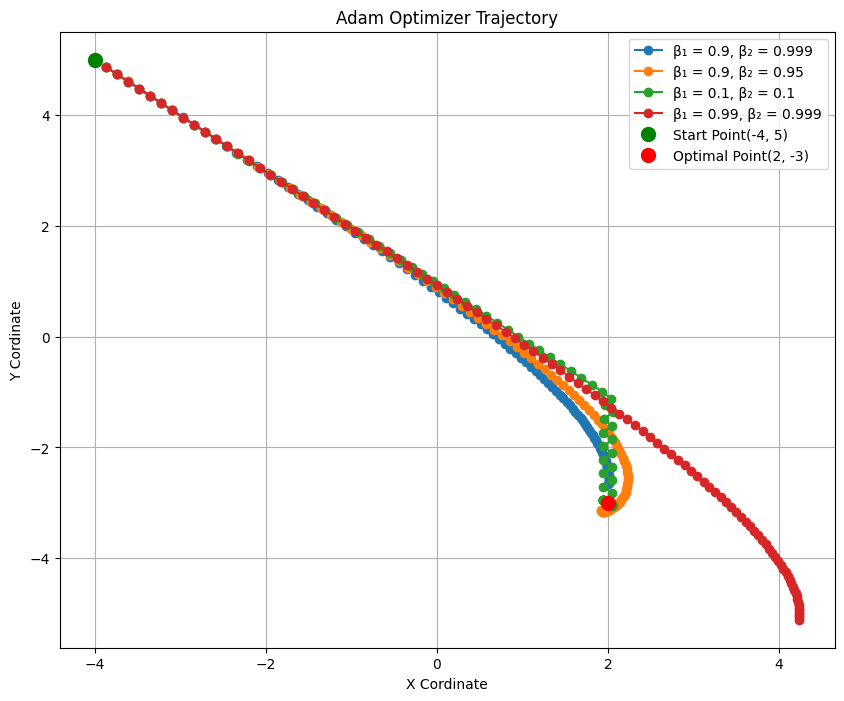

In [15]:
plt.figure(figsize=(10, 8))
for trajectory, label in adam_trajectories(betas_test):
    x_coor = [point[0] for point in trajectory]
    y_coor = [point[1] for point in trajectory]
    plt.plot(x_coor, y_coor, marker='o', label=label)

plt.plot(-4.0, 5.0, 'go', markersize=10, label='Start Point(-4, 5)')
plt.plot(2.0, -3.0, 'ro', markersize=10, label='Optimal Point(2, -3)')
plt.title('Adam Optimizer Trajectory')
plt.xlabel('X Cordinate')
plt.ylabel('Y Cordinate')
plt.legend()
plt.grid(True)
plt.show()

 Your task is to visualise different trajectories in a plot and analyse the results. Proceed as follows:

* Start by plotting the trajectory for the default values for $\beta_1$ and $\beta_2$. (Consult the PyTorch documentation to find these.)
* Add the plot for the beta values used in our training configuration. For this simple example, do you see a significant difference?

ANSWER: there are almost no differences between the blue and orange lines when the Beta values are almost the same. But we decrease the the Beta valuses (the green), it takes a sharp and jaggd angle and tryes to zig zog slowly. This can make the learning process very slow. When the beta values are too high, it goes pass the optimal point and not a good perfprmance at all. 

* Add more plots to see what happens if the beta values are too high or too low.

### Learning rate scheduling

Your next task is to implement the learning rate scheduler. As mentioned before, GPT-2 is trained with cosine decay from a maximum to a minimum learning rate in conjunction with a linear warmup phase.

#### 🎓 Task 3.06: Implementing cosine decay

Implement a function `get_lr_factor()` that determines the learning for a given `step`. To work with the rest of the implementation, this function should return its result as a factor of the maximum learning rate. In particular, the result at the end of the linear warmup should be&nbsp;$1$. Validate your implementation by plotting the function against the training steps.

In [16]:
def get_lr_factor(step: int, config: TrainingConfig) -> float:
    # TODO: Replace the next line with your own code
    #phase 1: Linear warmup
    if step < config.n_warmup_steps: # as long as the current training step (step) is less than the total number of warmup steps (config.n_warmup_steps), the function will return a learning rate factor that increases linearly from 0 to 1. This is achieved by returning the ratio of the current step to the total number of warmup steps (step / config.n_warmup_steps). For example, if step is 357 and n_warmup_steps is 715, the learning rate factor would be 0.5, meaning that the learning rate would be at 50% of its maximum value at that point in training.
        return step / config.n_warmup_steps # for example, if step is 357 and n_warmup_steps is 715, the learning rate factor would be 0.5, meaning that the learning rate would be at 50% of its maximum value at that point in training.
    #phase 2: Cosine decay
    decay_step = step - config.n_warmup_steps  # how many steps have been taken since the end of the warmup phase

    x = decay_step / config.n_decay_steps # between 0 and 1, how far we are into the decay phase
    x= min(x, 1.0) # ensure that x does not exceed 1.0
    cosine_decay = 0.5 * (1 + math.cos(math.pi * x))
    min_lr_ratio = config.min_lr / config.max_lr

    return min_lr_ratio + cosine_decay * (1 - min_lr_ratio)

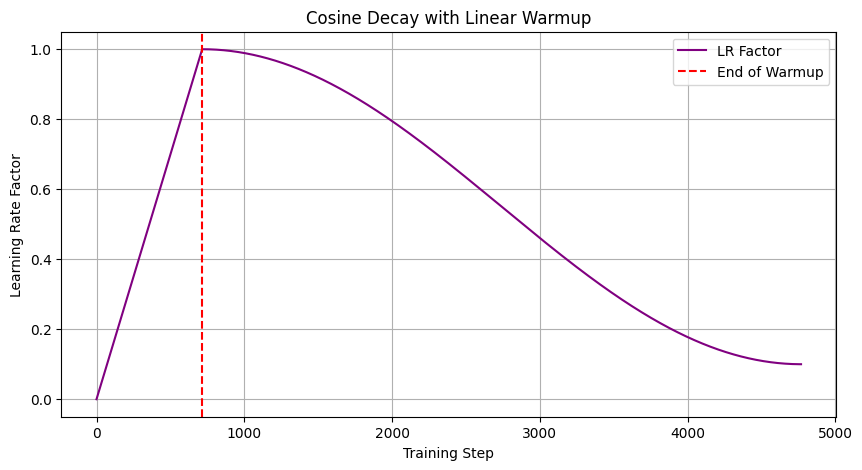

In [17]:
# 1. Initialize configuration
config = TrainingConfig()

# 2. Generate the LR factor for every single step in the training process
steps = range(config.n_steps)
lr_factors = [get_lr_factor(step, config) for step in steps]

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(steps, lr_factors, label="LR Factor", color="purple")

# Add helpful vertical lines to mark the phases
plt.axvline(x=config.n_warmup_steps, color='red', linestyle='--', label="End of Warmup")

plt.title("Cosine Decay with Linear Warmup")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate Factor")
plt.legend()
plt.grid(True)
plt.show()

RESULTS FROM THE DIAGRAM: 1: at the very begining (the purpule line), the learning rate is zero. 2: The linear warmup (0-715)-> the diagram shows that the function scales the learning reate learning rate linearly for exactly 715 steps until it reaches 100% of maximal learning rate. 3: After the red line the trajectory forms a smoth shape instead of dropping sharply in straight line. 4: at the far right of the grapg (step = 5000) the line flattens out perfectly horizontely at exactly y=1. 

**Hint:** For $x \in [0, 1]$, the relevant cosine decay is described by the term $\frac{1}{2} \cdot (1 + \text{cos}(\pi x))$.

### Training loop

At this point, we have everything in place to put together a first version of the training loop. Here it is:

In [ ]:
import torch
TORCHDYNAMO_VERBOSE=1 
def train(config: TrainingConfig):
    model = configure_model(config)
    model = model.to(config.device)
    model = torch.compile(model) # task 3.10: to optimize the model's performance by using PyTorch's Just-In-Time (JIT) compiler. This can help to speed up the training process by optimizing the execution of the model's operations, especially on compatible hardware such as GPUs. By compiling the model, we can potentially achieve faster training times and improved efficiency during the forward and backward passes of the training loop.
    print("Compiling model... (This may take a minute or two)") #task 3.11
    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)
    torch.set_float32_matmul_precision("high") # task 3.10: to set the precision for matrix multiplication operations to "high" when using 32-bit floating point numbers. This can help to improve the numerical stability and accuracy of the training process, especially when working with large models or datasets. By setting this precision, we can reduce the likelihood of encountering issues such as overflow or underflow during training, which can lead to better convergence and overall performance of the model.
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda lr: get_lr_factor(lr, config),
    )
    n_micro_steps = config.n_tokens_per_step // (
        config.batch_size * config.sequence_len
    )
    number_tokens_per_step = config.batch_size * config.sequence_len * n_micro_steps
    print(f"number_tokens_per_step: {number_tokens_per_step}") # The total number of tokens that will be processed in each training step, which is calculated as the product of the batch size, sequence length, and the number of micro-steps. This represents the actual number of tokens that will be fed into the model during each forward and backward pass, taking into account the gradient accumulation over multiple micro-batches. By calculating this value, we can better understand the computational load and memory requirements for each training step, as well as monitor the training speed in terms of tokens processed per second.
    print(f"n_micro_steps: {n_micro_steps}") # it is supposed to be 8, which means that we will process 8 micro-batches of data before updating the model's weights. Each micro-batch will contain a portion of the total tokens that we want to process in each training step, allowing us to effectively manage memory usage while still benefiting from the advantages of larger batch sizes for training stability and convergence.
    for step in range(config.n_steps):
        t0 = time.time() # start time
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)
            with torch.autocast(device_type=config.device.type, dtype=torch.bfloat16):
                logits = model(x)
                loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1)) #task 3.10
            loss = loss / n_micro_steps # to average the loss over the micro-steps, which is a common practice when using gradient accumulation. By dividing the loss by the number of micro-steps (n_micro_steps), we ensure that the gradients are scaled appropriately and that the overall training process remains stable. This helps to prevent issues such as exploding gradients or unstable updates to the model's weights when using smaller micro-batches for training.
            loss.backward()
            running_loss += loss.item() * n_micro_steps # to get the total loss for the entire batch, we multiply the average loss (loss.item()) by the number of micro-steps (n_micro_steps). This gives us the total loss for the batch, which can be used for logging and monitoring the training process. By accumulating the loss in this way, we can track how the model's performance evolves over time and make adjustments to the training process if necessary.
        nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
        optimizer.step()

        if config.device.type == "cuda":
            torch.cuda.synchronize() # to ensure that all CUDA operations have completed before measuring the time taken for the training step. This is important because CUDA operations are asynchronous, and without this synchronization, the timing might not accurately reflect the time taken for the training step, as it could include time spent on other operations that are still in progress on the GPU.
        t1 = time.time() # end time
        dt = t1 - t0
        tokens_per_sec = number_tokens_per_step / dt
        print(f"Step {step:4d} | Loss: {running_loss:.4f} | Time: {dt*1000:.2f}ms | Speed: {tokens_per_sec:.2f} tokens/sec")

        lr = scheduler.get_last_lr()[0]
        scheduler.step()
        print(f"step {step:4d} | loss: {running_loss:.4f} | lr: {lr:.4e}")

Most of the steps should look familiar from previous labs or earlier tasks in this notebook. However, a few key aspects will be new:

**Moving the model and data to the training device.** The model and each batch are moved to the training device using `.to()`. In our training configuration, `config.device` is an NVIDIA GPU, which supports fast tensor computations.

**Gradient accumulation.** Instead of taking an optimisation step after every batch, we accumulate gradients over multiple batches (“micro-steps”). Each batch contributes to the gradients using `loss.backward()`.

**Gradient clipping.** Before updating weights, the gradients are clipped using `clip_grad_norm_()`. This prevents excessively large updates that could destabilise training. The clipping threshold is set by `config.clip_norm`.

#### 🧩 Task 3.07: Running the training loop

Try to train a model by executing the code below:

In [24]:
train(TrainingConfig())

Compiling model... (This may take a minute or two)
number_tokens_per_step: 524288
n_micro_steps: 64
token_per_batch: 8192
chunk_size: 8193
Initial buffer size: 0
Tokens in buffer: 100000000, Batches: 12207


InductorError: PermissionError: [Errno 13] Permission denied: 'nvcc'

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"


You will run into two problems:

**Memory issues.** The training configuration for our Model&nbsp;B has been set up for an A100 GPU with 80GB of memory. If you are using a less powerful GPU, you will see an out-of-memory error. To fix this, reduce the batch size to lower the memory load on the GPU. Start with a value of&nbsp;4. Then, try doubling this value until you find the largest batch size that fits on your GPU. Note that you may have to restart the Jupyter kernel to reset the GPU after each adjustment.

ANSWER: We got the error regarding CUDA out of memory when we changed the batch size to 16. So the maximum batch size is 8. 

**High losses.** The training losses start at very high values. Recall that the model’s goal is to predict the next token. At the start, the model’s weights are random, so we expect it to output a uniform distribution over the vocabulary. This means each token should have a probability of $1/V$, where $V$ is the vocabulary size. Given this, what should the initial loss be? Think about the cross-entropy loss for a uniform distribution.

(You will fix the problem with the high losses in the next task.)

#### 🎓 Task 3.08: Fixing the gradient accumulation

The gradient accumulation in the `train()` function is not implemented correctly. To see this, consider the following example. We set up a linear layer and pass in some random input of shape $[2, 3]$. First, we compute the loss and gradients in the normal way. Then, we do the same thing using gradient accumulation over two singleton batches, in the way this is implemented in `train()`. As you will see, the two outputs are different.

In [ ]:
def accumulation_example():
    # Set up a simple model and simulate some input
    torch.manual_seed(42)  # to keep the numbers consistent for testing
    model = nn.Linear(3, 2) # a simple linear model with 3 input features and 2 output features. This model will be used to demonstrate the concept of gradient accumulation.
    x = torch.randn(2, 3) # Simulate a batch of 2 sequences, each with 3 tokens (features). The shape of x is (2, 3), where 2 is the batch size and 3 is the number of features for each sequence.
    y = torch.randint(0, 2, (2,)) # Simulate target labels for the batch, where each label is an integer between 0 and 1 (inclusive). The shape of y is (2,), which corresponds to the batch size of 2. Each element in y represents the target class for the corresponding sequence in x.

    # Compute the gradient on the complete input
    model.zero_grad()
    output = model(x)
    loss = F.cross_entropy(output, y)
    loss.backward()
    # print(model.weight.grad)
    print(f"true gradients\n: {model.weight.grad}")

    # Compute the gradient using micro-batches (flawed)
    model.zero_grad()
    for i in range(2): # 2 micro-batches, each containing 1 sequence of 3 tokens, the shape of x[i : i + 1] is (1, 3) and the shape of y[i : i + 1] is (1,). The loop iterates over the two sequences in the input data, computes the output and loss for each micro-batch, and accumulates the gradients by calling loss.backward() for each micro-batch. However, this approach is flawed because it does not properly account for the dependencies between the micro-batches, which can lead to incorrect gradient calculations and suboptimal training performance.
        output = model(x[i : i + 1]) # output is the result of passing the micro-batch (x[i : i + 1]) through the model. The shape of output will be (1, 2), where 1 is the batch size of the micro-batch and 2 is the number of output features from the model. This output will be used to compute the loss for the micro-batch, which will then be backpropagated to accumulate gradients for each micro-batch.
        loss = F.cross_entropy(output, y[i : i + 1])
        loss = loss / 2 # to average the loss over the micro-batches, which is a common practice when using gradient accumulation. By dividing the loss by the number of micro-batches (in this case, 2), we ensure that the gradients are scaled appropriately and that the overall training process remains stable. This helps to prevent issues such as exploding gradients or unstable updates to the model's weights when using smaller micro-batches for training.
        loss.backward() # backpropagate the loss for the current micro-batch to accumulate gradients. This will update the gradients of the model's parameters based on the loss computed for the current micro-batch, allowing for gradient accumulation across multiple micro-batches before performing an optimizer step.


    print(f"accumulated gradients\n: {model.weight.grad}")


accumulation_example()

Your task is to fix the flawed implementation of gradient accumulation in the training loop.

1. Propose a fix for the problem illustrated in the example.
2. Validate your proposal by modifying the example.
3. Once you are convinced that your fix is correct, apply it to the training loop.
4. How does the fix affect the loss? ANSWER: the fix mathematically shrinks the loss tensor by a factor of n_micro_steps before the backward pass. without the fix the gradients whould be 8 times (524288/65536=8 times) larger, leading to massive overshooting. 

## Part 2: Efficiency optimisations

Training LLMs from scratch is a computationally intensive task. Efficient training not only speeds up model convergence but also reduces hardware costs and energy consumption. As models grow in size, optimising the training process becomes increasingly important to ensure that resources are used effectively. In the second part of this lab, we will look into a few such optimisation techniques.

#### 🎓 Task 3.09: Profiling the training loop

Before we explore optimisations, we first need a way to measure training speed. We will define training speed as the **number of tokens processed per second**. Your task is to implement this measurement in the training loop.

**Step&nbsp;1.** Keep track of the number of tokens processed in each optimisation step.

**Step&nbsp;2.** Add a timer to measure the time taken per step. For accurate results, call `torch.cuda.synchronize()` before stopping the timer. This ensures all GPU computations finish before recording the time.

Once you have added this measurement, train the model for a few steps and answer the following questions:

* Based on your measured training speed, how long would it take to train on the toy data for this lab (300M tokens)? ANSWER: (30000000 / ~12400(tokens/sec)) / 60 = ~40 minutes 

* How much data and time would be required to train the full, Chinchilla-optimal Model&nbsp;B on your computer?  

### Floating-point representations

One of the optimisations we can make when training large language models is choosing an appropriate floating-point representation. A floating-point number is represented using three components: a **sign bit**, an **exponent**, and a **fraction** (also called mantissa). The number of bits assigned to the exponent determines the *range* of the representation, while the number of bits in the fraction determines the *precision*.

The most commonly used floating-point format is single-precision floating point (fp32), which uses 1&nbsp;sign bit, 8&nbsp;exponent bits, and 23&nbsp;fraction bits. However, most deep learning computations do not require the full 23-bit precision of fp32. As a result, modern hardware supports lower-precision formats that improve performance and memory efficiency while maintaining training stability. We are particularly interested in two of those:

**TensorFloat-32 (tf32)** is a precision format introduced by NVIDIA. It keeps the same 8-bit exponent as fp32, preserving the same numerical range. However, tf32 reduces the fraction size to 10 bits, leading to lower precision but faster matrix multiplications on dedicated GPUs.

**Brain Floating Point 16 (bf16)** is another reduced precision format widely used in NVIDIA GPUs. Like tf32, bf16 has the same 8-bit exponent as fp32, and therefore, the same range. However, bf16 has only 7 bits for the fraction. Unlike tf32, which is primarily used for internal computations, bf16 can be directly stored and used for activations, weights, and gradients, which can save memory (16 bits per value instead of 32).

#### 🧩 Task 3.10: Exploring floating-point representations

Your task is to rewrite the training loop to take advantage of specialised floating-point representations.

**Step&nbsp;1.** By default, PyTorch uses the fp32 format for internal computations (“highest precision”). Read the documentation of [`torch.set_float32_matmul_precision()`](https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html) to find out how to change this default and use tf32 if possible.

**Step&nbsp;2.** Computing the forward pass and the loss requires even less precision than other parts of the training loop. Read the documentation of [`torch.autocast()`](https://pytorch.org/docs/stable/amp.html#torch.autocast) to find out how to execute these operations using the bf16 format.

**Step&nbsp;3.** Repeat your profiling experiments with the modified training loop. How much time would be required to train the model now that you have implemented the floating-point optimisations? (30000000 / ~40000) / 60 = 12.5 Minutes.

### Just-in-time compilation

The second optimisation we will explore is **just-in-time (JIT) compilation** – a technique to speed up code by compiling it at runtime, rather than before execution. This allows the compiler to optimise the code dynamically based on actual inputs and hardware conditions.

PyTorch provides a function [`torch.compile()`](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html) that uses JIT compilation to automatically optimise deep learning models. Instead of executing PyTorch operations one by one, this function analyses the computation, restructures it, and generates highly efficient machine code. This optimised code can often be run as a single fused operation on the GPU.

The performance boost from JIT compilation is especially noticeable on high-end GPUs like the NVIDIA A100 or H100, but it can still provide smaller speedups on less powerful GPUs.

#### 🧩 Task 3.11: Exploring just-in-time compilation

In this task, you will measure how much `torch.compile()` improves the training speed. To enable JIT compilation, add the following line to the training loop:

```
model = torch.compile(model)
```

Make sure to place this *after* moving the model to the training device so the optimisation can be tailored to the hardware you are using. Once you have enabled JIT compilation, rerun your profiling experiments and compare the training speed before and efter.

## Part 3: Evaluate the pre-trained model

This notebook contains all the code needed to train a Chinchilla-optimal model on the FineWeb-Edu dataset. However, training on the full dataset is not practical within the time and resource limits of this lab.

To save time, we provide a pretrained Model&nbsp;B that was trained using the exact same settings you developed earlier. The only difference is that we used a compute node with 8 NVIDIA A100 GPUs (80GB each). With this setup, a full training run takes about 30 minutes.

We provide the trained model in the file `gpt-2-fineweb-edu.pt`. You can load it with the following code:

In [32]:
pretrained = Model(Config(n_vocab=50304))
pretrained.load_state_dict(torch.load("gpt-2-fineweb-edu.pt"))
pretrained.lm_head.weight = pretrained.wte.weight

FileNotFoundError: [Errno 2] No such file or directory: 'gpt-2-fineweb-edu.pt'

#### 🎓 Task 3.12: Evaluating the pretrained model

The next cell contains code for evaluating Model&nbsp;B on the same small sample from the [HellaSwag](https://rowanzellers.com/hellaswag/) benchmark you already used in lab&nbsp;2 when evaluating the original Model&nbsp;A. How do the scores compare? What does this result tell you about the impact of data quality on the downstream performance of language models?

In [ ]:
import json

import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

with open("hellaswag-mini.jsonl") as f:
    n_correct = 0
    n_total = 0
    for line in f:
        sample = json.loads(line)
        prefix = tokenizer.encode(sample["ctx"])
        ending_scores = []
        for i, ending in enumerate(sample["endings"]):
            suffix = tokenizer.encode(" " + ending)
            context = torch.tensor([prefix + suffix], dtype=torch.long)
            with torch.no_grad():
                logits = pretrained(context)
                ending_score = torch.nn.functional.cross_entropy(
                    logits[0, -len(suffix) - 1 : -1], context[0, -len(suffix) :]
                )
            ending_scores.append((ending_score, i))
        predicted = min(ending_scores)[1]
        n_correct += int(predicted == sample["label"])
        n_total += 1
    print(f"Accuracy: {n_correct / n_total:.2%}")

**🥳 Congratulations on finishing lab&nbsp;3!**